# Gradient Descent for Logistic Regression

In [1]:
import copy,math
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from function import dlc, plot_data, plt_tumor_data, sigmoid, compute_cost_logistic
from function import plt_quad_logistic, plt_prob

In [2]:
# Data
X_train = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train = np.array([0, 0, 0, 1, 1, 1])

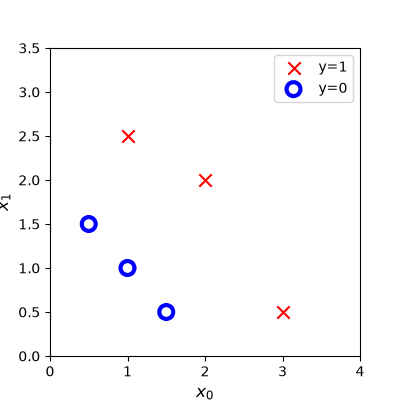

In [3]:
fig,ax = plt.subplots(1,1,figsize=(4,4))
plot_data(X_train,y_train,ax)

ax.axis([0,4,0,3.5])
ax.set_ylabel('$x_1$',fontsize=12)
ax.set_xlabel('$x_0$',fontsize=12)
plt.show()

## Logistic Gradient Descent
- gradient calculation:  
  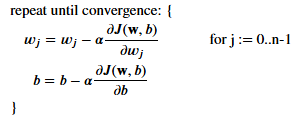  
- each iteration performs simultaneous update on $w_j$ for all j, where  
  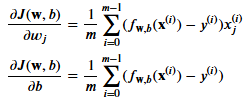

### Gradient Descent Implementation

In [4]:
def compute_gradient_logistic(X,y,w,b):
    m,n = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0

    for i in range(m):
        f_wb_i = sigmoid(np.dot(X[i],w) + b)
        err_i = f_wb_i - y[i]
        for j in range(n):
            dj_dw[j] += err_i * X[i,j]
        dj_db += err_i

    dj_dw = dj_dw/m
    dj_db = dj_db/m

    return dj_db,dj_dw

In [5]:
X_tmp = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_tmp = np.array([0, 0, 0, 1, 1, 1])
w_tmp = np.array([2.,3.])
b_tmp = 1

dj_db_tmp,dj_dw_tmp = compute_gradient_logistic(X_tmp,y_tmp,w_tmp,b_tmp)
print(f"dj_db: {dj_db_tmp}")
print(f"dj_dw: {dj_dw_tmp.tolist()}")

dj_db: 0.49861806546328574
dj_dw: [0.498333393278696, 0.49883942983996693]


#### Gradient Descent Code

In [6]:
def gradient_descent(X,y,w_in,b_in,alpha,num_iters):
    j_history = []
    w = copy.deepcopy(w_in)
    b = b_in

    for i in range(num_iters):

        dj_db,dj_dw = compute_gradient_logistic(X,y,w,b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if i < 100000:
            j_history.append(compute_cost_logistic(X,y,w,b))

        if i % math.ceil(num_iters/10) == 0:
            print(f"iteration: {i:4d}, cost: {j_history[-1]}")

    return w,b,j_history

In [7]:
w_tmp = np.zeros_like(X_train[0])
# .zeros_like() creates an array of zeros as same size and dtype of input parameter

b_tmp = 0.
alpha = 0.1
iters = 10000

w_out,b_out,_ = gradient_descent(X_train,y_train,w_tmp,b_tmp,alpha,iters)
print(f"\nupdated parameters: w:{w_out}, b:{b_out}")

iteration:    0, cost: 0.684610468560574
iteration: 1000, cost: 0.1590977666870456
iteration: 2000, cost: 0.08460064176930081
iteration: 3000, cost: 0.05705327279402531
iteration: 4000, cost: 0.042907594216820076
iteration: 5000, cost: 0.034338477298845684
iteration: 6000, cost: 0.028603798022120097
iteration: 7000, cost: 0.024501569608793
iteration: 8000, cost: 0.02142370332569295
iteration: 9000, cost: 0.019030137124109114

updated parameters: w:[5.28123029 5.07815608], b:-14.222409982019837


##### Plot the result of gradient descent

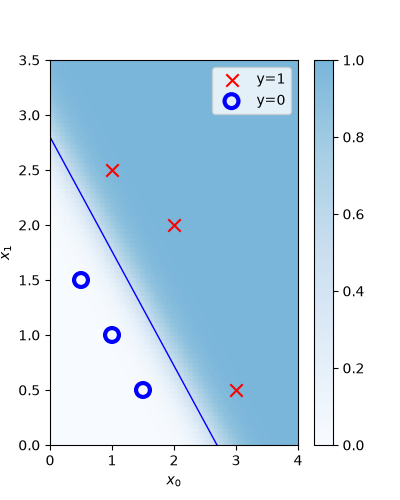

In [8]:
fig,ax = plt.subplots(1,1,figsize=(4,5))

plt_prob(ax,w_out,b_out)

ax.set_ylabel("$x_1$")
ax.set_xlabel("$x_0$")
ax.axis([0,4,0,3.5])
plot_data(X_train,y_train,ax)

x0 = -b_out/w_out[0]
x1 = -b_out/w_out[1]

ax.plot([0,x0],[x1,0],c="blue",lw=1)
plt.show()

### Another dataset

In [9]:
x_train = np.array([0., 1, 2, 3, 4, 5])
y_train = np.array([0,  0, 0, 1, 1, 1])

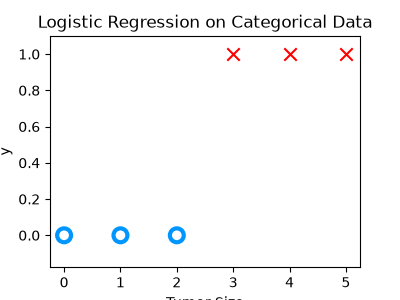

In [10]:
fig,ax = plt.subplots(1,1,figsize=(4,3))
plt_tumor_data(x_train,y_train,ax)
plt.show()

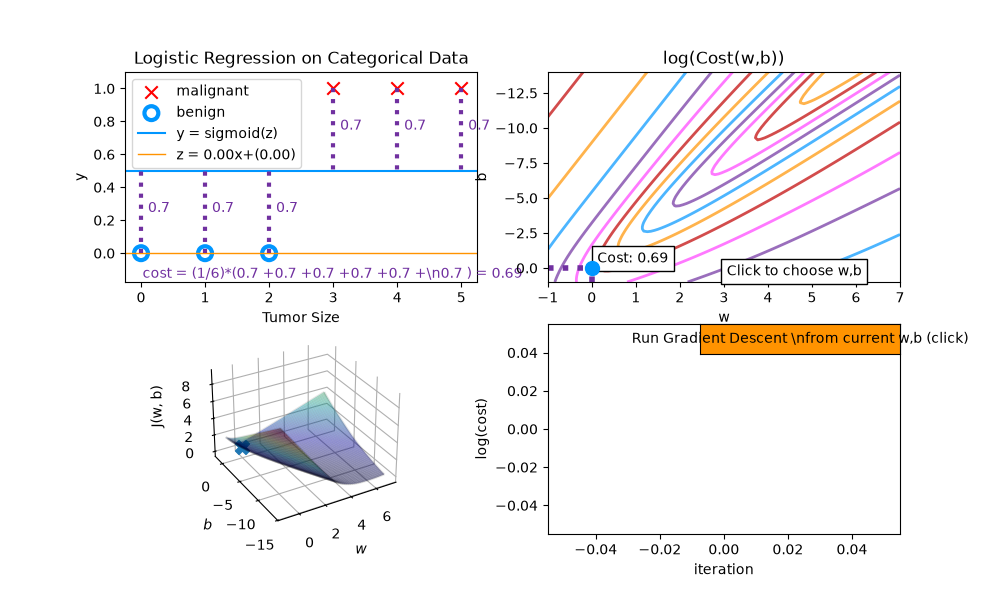

In [11]:
w_range = np.array([-1, 7])
b_range = np.array([1, -14])
quad = plt_quad_logistic( x_train, y_train, w_range, b_range )